In [1]:
import importlib
import sys
import numpy as np
from collections import Counter
import pandas as pd

# performance imports for torch: torch kernel uses one core only.
import os
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["TORCH_NUM_THREADS"] = "1" 

import torch

sys.path.insert(0, '..')
sys.path.insert(0, '../..')
sys.path.insert(0, '../../..')

In [2]:
import event_log_loader.new_event_log_loader_v2
importlib.reload(event_log_loader.new_event_log_loader_v2)
from event_log_loader.new_event_log_loader_v2 import PrefixesDataFrameLoader, EventLogLoader

import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

np.random.seed(17)

event_log_location = '../../../../../../data/data/DomesticDeclarations.csv'

result_name = 'bpic20_DD_all'

# dynamic categorical attributes
cat_dynamic = ['concept:name',
               'org:resource',
               'org:role'
              ]

# static categorical attributes
cat_static = [#'case:BudgetNumber',
              #'case:DeclarationNumber'
             ]

# dynamic numerical attributes
num_dynamic = ['case_elapsed_time',
               'event_elapsed_time',
               'day_in_week',
               'seconds_in_day',
               ]

# dynamic log-normal encoded numerical attributes 
num_dyn_log = []

# static numeric attributes
num_static = ['case:Amount']

min_suffix_size = 5

# 15% test size:
test_validation_size = 0.15

event_log_properties = {# case id
                        'case_name' : 'case:concept:name',
                        # activity
                        'concept_name' : 'concept:name',
                        # time values and computaitons
                        'timestamp_name' : 'time:timestamp',
                        'time_since_case_start_column' : 'case_elapsed_time',
                        'time_since_last_event_column' : 'event_elapsed_time',
                        'day_in_week_column' : 'day_in_week',
                        'seconds_in_day_column' : 'seconds_in_day',
                        # min suffix size for eos padding right
                        'min_suffix_size' : min_suffix_size,
                        # trian and test split
                        # 'train_validation_size' : 0.15,
                        # 'test_validation_size' : 0.2,
                        'train_validation_size' : test_validation_size / (1-test_validation_size), # ensures that val used as cal set has same size as test set
                        'test_validation_size' :test_validation_size,
                        # window size for padding
                        'window_size' : 'auto',
                        # dynamic and static values
                        'categorical_columns' : cat_dynamic,
                        'static_categorical_columns' : cat_static,
                        'continuous_columns' : num_dynamic,
                        'continuous_positive_columns' : num_dyn_log,
                        'static_continuous_columns' : num_static}


## Create dataframes of prefixes

In [3]:
# object to create datframe of prefixes for petri-net repaly marking computation
pref_adopt_dataframe = PrefixesDataFrameLoader(event_log_location=event_log_location, event_log_properties=event_log_properties)

In [4]:
# output if necessary the raw dataframe: dynamic are lists, static values
raw_data = pref_adopt_dataframe.get_raw_dataframe()
raw_data

unique_vals = (
    pd.Series(raw_data["concept:name"])
      .explode()
      .dropna()
      .unique()
      .tolist()
)

print(unique_vals)

['Declaration SUBMITTED by EMPLOYEE', 'Declaration APPROVED by ADMINISTRATION', 'Declaration FINAL_APPROVED by SUPERVISOR', 'Request Payment', 'Payment Handled', 'Declaration APPROVED by BUDGET OWNER', 'Declaration REJECTED by ADMINISTRATION', 'Declaration REJECTED by EMPLOYEE', 'Declaration APPROVED by PRE_APPROVER', 'Declaration REJECTED by MISSING', 'Declaration REJECTED by SUPERVISOR', 'Declaration REJECTED by BUDGET OWNER', 'Declaration SAVED by EMPLOYEE', 'Declaration REJECTED by PRE_APPROVER', 'Declaration FOR_APPROVAL by ADMINISTRATION', 'Declaration FOR_APPROVAL by SUPERVISOR', 'Declaration FOR_APPROVAL by PRE_APPROVER']


In [5]:
# outputs for perturbations:
# train_df, val_df, test_df = pref_adopt_dataframe.get_all_datasets()
# categories = pref_adopt_dataframe.extract_feature_info()

In [6]:
# prefix dataset for potential marking computation
train_pref_df = pref_adopt_dataframe.get_dataset('train')
train_pref_df

,case:concept:name,prefix_length,concept:name,org:resource,org:role,case_elapsed_time,event_elapsed_time,day_in_week,seconds_in_day,case:Amount
0,declaration 100005,1,[Declaration SUBMITTED by EMPLOYEE],[STAFF MEMBER],[EMPLOYEE],[0.0],[nan],[1.0],[34734.0],35.133685
1,declaration 100005,2,"[Declaration SUBMITTED by EMPLOYEE, Declaratio...","[STAFF MEMBER, STAFF MEMBER]","[EMPLOYEE, ADMINISTRATION]","[0.0, 3.0]","[nan, 3.0]","[1.0, 1.0]","[34734.0, 34737.0]",35.133685
2,declaration 100005,3,"[Declaration SUBMITTED by EMPLOYEE, Declaratio...","[STAFF MEMBER, STAFF MEMBER, STAFF MEMBER]","[EMPLOYEE, ADMINISTRATION, SUPERVISOR]","[0.0, 3.0, 1516.0]","[nan, 3.0, 1513.0]","[1.0, 1.0, 1.0]","[34734.0, 34737.0, 36250.0]",35.133685
3,declaration 100005,4,"[Declaration SUBMITTED by EMPLOYEE, Declaratio...","[STAFF MEMBER, STAFF MEMBER, STAFF MEMBER, SYS...","[EMPLOYEE, ADMINISTRATION, SUPERVISOR, UNDEFINED]","[0.0, 3.0, 1516.0, 97584.0]","[nan, 3.0, 1513.0, 96068.0]","[1.0, 1.0, 1.0, 2.0]","[34734.0, 34737.0, 36250.0, 45918.0]",35.133685
4,declaration 100005,5,"[Declaration SUBMITTED by EMPLOYEE, Declaratio...","[STAFF MEMBER, STAFF MEMBER, STAFF MEMBER, SYS...","[EMPLOYEE, ADMINISTRATION, SUPERVISOR, UNDEFIN...","[0.0, 3.0, 1516.0, 97584.0, 201143.0]","[nan, 3.0, 1513.0, 96068.0, 103559.0]","[1.0, 1.0, 1.0, 2.0, 3.0]","[34734.0, 34737.0, 36250.0, 45918.0, 63077.0]",35.133685
...,...,...,...,...,...,...,...,...,...,...
38021,declaration 99995,1,[Declaration SUBMITTED by EMPLOYEE],[STAFF MEMBER],[EMPLOYEE],[0.0],[nan],[0.0],[75538.0],26.218933
38022,declaration 99995,2,"[Declaration SUBMITTED by EMPLOYEE, Declaratio...","[STAFF MEMBER, STAFF MEMBER]","[EMPLOYEE, ADMINISTRATION]","[0.0, 11.0]","[nan, 11.0]","[0.0, 0.0]","[75538.0, 75549.0]",26.218933
38023,declaration 99995,3,"[Declaration SUBMITTED by EMPLOYEE, Declaratio...","[STAFF MEMBER, STAFF MEMBER, STAFF MEMBER]","[EMPLOYEE, ADMINISTRATION, SUPERVISOR]","[0.0, 11.0, 61180.0]","[nan, 11.0, 61169.0]","[0.0, 0.0, 1.0]","[75538.0, 75549.0, 50318.0]",26.218933
38024,declaration 99995,4,"[Declaration SUBMITTED by EMPLOYEE, Declaratio...","[STAFF MEMBER, STAFF MEMBER, STAFF MEMBER, SYS...","[EMPLOYEE, ADMINISTRATION, SUPERVISOR, UNDEFINED]","[0.0, 11.0, 61180.0, 140047.0]","[nan, 11.0, 61169.0, 78867.0]","[0.0, 0.0, 1.0, 2.0]","[75538.0, 75549.0, 50318.0, 42785.0]",26.218933


In [7]:
train_pref_df.to_csv('../../../../encoded_data_conformal/BPIC20_DD/prefix_for_replay/'+result_name+'_'+str(min_suffix_size)+'_train.csv', index=False)

In [8]:
# prefix dataset for potential marking computation
val_pref_df = pref_adopt_dataframe.get_dataset('val')
val_pref_df

,case:concept:name,prefix_length,concept:name,org:resource,org:role,case_elapsed_time,event_elapsed_time,day_in_week,seconds_in_day,case:Amount
0,declaration 100000,1,[Declaration SUBMITTED by EMPLOYEE],[STAFF MEMBER],[EMPLOYEE],[0.0],[nan],[1.0],[33607.0],600.844121
1,declaration 100000,2,"[Declaration SUBMITTED by EMPLOYEE, Declaratio...","[STAFF MEMBER, STAFF MEMBER]","[EMPLOYEE, ADMINISTRATION]","[0.0, 693519.0]","[nan, 693519.0]","[1.0, 2.0]","[33607.0, 35926.0]",600.844121
2,declaration 100000,3,"[Declaration SUBMITTED by EMPLOYEE, Declaratio...","[STAFF MEMBER, STAFF MEMBER, STAFF MEMBER]","[EMPLOYEE, ADMINISTRATION, SUPERVISOR]","[0.0, 693519.0, 783538.0]","[nan, 693519.0, 90019.0]","[1.0, 2.0, 3.0]","[33607.0, 35926.0, 39545.0]",600.844121
3,declaration 100000,4,"[Declaration SUBMITTED by EMPLOYEE, Declaratio...","[STAFF MEMBER, STAFF MEMBER, STAFF MEMBER, SYS...","[EMPLOYEE, ADMINISTRATION, SUPERVISOR, UNDEFINED]","[0.0, 693519.0, 783538.0, 876162.0]","[nan, 693519.0, 90019.0, 92624.0]","[1.0, 2.0, 3.0, 4.0]","[33607.0, 35926.0, 39545.0, 45769.0]",600.844121
4,declaration 100000,5,"[Declaration SUBMITTED by EMPLOYEE, Declaratio...","[STAFF MEMBER, STAFF MEMBER, STAFF MEMBER, SYS...","[EMPLOYEE, ADMINISTRATION, SUPERVISOR, UNDEFIN...","[0.0, 693519.0, 783538.0, 876162.0, 1152673.0]","[nan, 693519.0, 90019.0, 92624.0, 276511.0]","[1.0, 2.0, 3.0, 4.0, 0.0]","[33607.0, 35926.0, 39545.0, 45769.0, 63080.0]",600.844121
...,...,...,...,...,...,...,...,...,...,...
9934,declaration 99939,1,[Declaration SUBMITTED by EMPLOYEE],[STAFF MEMBER],[EMPLOYEE],[0.0],[nan],[4.0],[48682.0],131.747751
9935,declaration 99939,2,"[Declaration SUBMITTED by EMPLOYEE, Declaratio...","[STAFF MEMBER, STAFF MEMBER]","[EMPLOYEE, ADMINISTRATION]","[0.0, 3354.0]","[nan, 3354.0]","[4.0, 4.0]","[48682.0, 52036.0]",131.747751
9936,declaration 99939,3,"[Declaration SUBMITTED by EMPLOYEE, Declaratio...","[STAFF MEMBER, STAFF MEMBER, STAFF MEMBER]","[EMPLOYEE, ADMINISTRATION, SUPERVISOR]","[0.0, 3354.0, 3503.0]","[nan, 3354.0, 149.0]","[4.0, 4.0, 4.0]","[48682.0, 52036.0, 52185.0]",131.747751
9937,declaration 99939,4,"[Declaration SUBMITTED by EMPLOYEE, Declaratio...","[STAFF MEMBER, STAFF MEMBER, STAFF MEMBER, SYS...","[EMPLOYEE, ADMINISTRATION, SUPERVISOR, UNDEFINED]","[0.0, 3354.0, 3503.0, 327423.0]","[nan, 3354.0, 149.0, 323920.0]","[4.0, 4.0, 4.0, 1.0]","[48682.0, 52036.0, 52185.0, 30505.0]",131.747751


In [9]:
val_pref_df.to_csv('../../../../encoded_data_conformal/BPIC20_DD/prefix_for_replay/'+result_name+'_'+str(min_suffix_size)+'_val.csv', index=False)

In [10]:
# prefix dataset for potential marking computation
test_pref_df = pref_adopt_dataframe.get_dataset('test')
test_pref_df

,case:concept:name,prefix_length,concept:name,org:resource,org:role,case_elapsed_time,event_elapsed_time,day_in_week,seconds_in_day,case:Amount
0,declaration 100042,1,[Declaration SUBMITTED by EMPLOYEE],[STAFF MEMBER],[EMPLOYEE],[0.0],[nan],[4.0],[50122.0],61.800099
1,declaration 100042,2,"[Declaration SUBMITTED by EMPLOYEE, Declaratio...","[STAFF MEMBER, STAFF MEMBER]","[EMPLOYEE, ADMINISTRATION]","[0.0, 7.0]","[nan, 7.0]","[4.0, 4.0]","[50122.0, 50129.0]",61.800099
2,declaration 100042,3,"[Declaration SUBMITTED by EMPLOYEE, Declaratio...","[STAFF MEMBER, STAFF MEMBER, STAFF MEMBER]","[EMPLOYEE, ADMINISTRATION, BUDGET OWNER]","[0.0, 7.0, 249920.0]","[nan, 7.0, 249913.0]","[4.0, 4.0, 0.0]","[50122.0, 50129.0, 40842.0]",61.800099
3,declaration 100042,4,"[Declaration SUBMITTED by EMPLOYEE, Declaratio...","[STAFF MEMBER, STAFF MEMBER, STAFF MEMBER, STA...","[EMPLOYEE, ADMINISTRATION, BUDGET OWNER, SUPER...","[0.0, 7.0, 249920.0, 832830.0]","[nan, 7.0, 249913.0, 582910.0]","[4.0, 4.0, 0.0, 0.0]","[50122.0, 50129.0, 40842.0, 18952.0]",61.800099
4,declaration 100042,5,"[Declaration SUBMITTED by EMPLOYEE, Declaratio...","[STAFF MEMBER, STAFF MEMBER, STAFF MEMBER, STA...","[EMPLOYEE, ADMINISTRATION, BUDGET OWNER, SUPER...","[0.0, 7.0, 249920.0, 832830.0, 928781.0]","[nan, 7.0, 249913.0, 582910.0, 95951.0]","[4.0, 4.0, 0.0, 0.0, 1.0]","[50122.0, 50129.0, 40842.0, 18952.0, 28503.0]",61.800099
...,...,...,...,...,...,...,...,...,...,...
8467,declaration 99968,1,[Declaration SUBMITTED by EMPLOYEE],[STAFF MEMBER],[EMPLOYEE],[0.0],[nan],[0.0],[35660.0],44.053931
8468,declaration 99968,2,"[Declaration SUBMITTED by EMPLOYEE, Declaratio...","[STAFF MEMBER, STAFF MEMBER]","[EMPLOYEE, ADMINISTRATION]","[0.0, 3.0]","[nan, 3.0]","[0.0, 0.0]","[35660.0, 35663.0]",44.053931
8469,declaration 99968,3,"[Declaration SUBMITTED by EMPLOYEE, Declaratio...","[STAFF MEMBER, STAFF MEMBER, STAFF MEMBER]","[EMPLOYEE, ADMINISTRATION, SUPERVISOR]","[0.0, 3.0, 357798.0]","[nan, 3.0, 357795.0]","[0.0, 0.0, 4.0]","[35660.0, 35663.0, 47858.0]",44.053931
8470,declaration 99968,4,"[Declaration SUBMITTED by EMPLOYEE, Declaratio...","[STAFF MEMBER, STAFF MEMBER, STAFF MEMBER, SYS...","[EMPLOYEE, ADMINISTRATION, SUPERVISOR, UNDEFINED]","[0.0, 3.0, 357798.0, 687905.0]","[nan, 3.0, 357795.0, 330107.0]","[0.0, 0.0, 4.0, 1.0]","[35660.0, 35663.0, 47858.0, 32365.0]",44.053931


In [11]:
test_pref_df.to_csv('../../../../encoded_data_conformal/BPIC20_DD/prefix_for_replay/'+result_name+'_'+str(min_suffix_size)+'_test.csv', index=False)

## Optional: Compute Petri Net replay markings of prefixes 

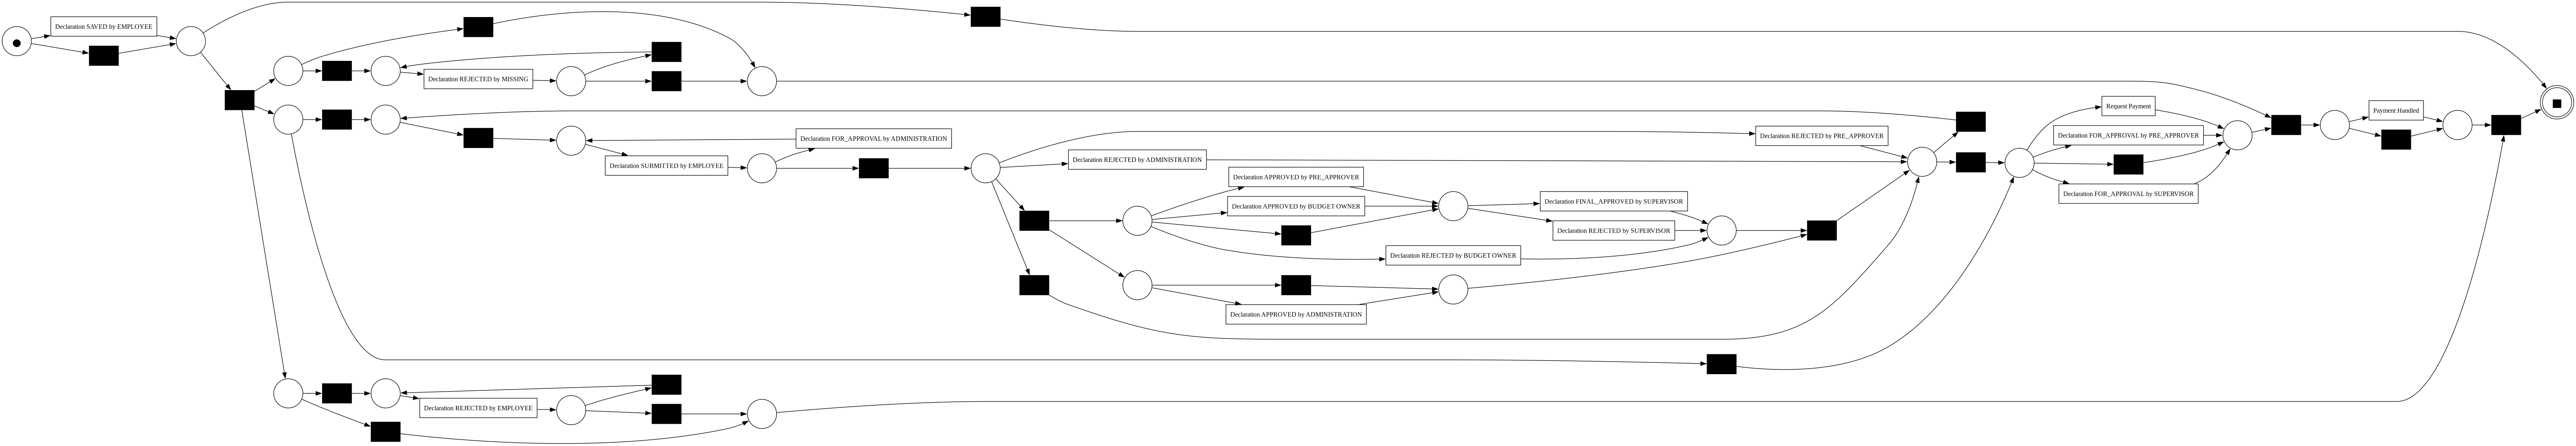

In [12]:
# Calculate and store markings:
import event_log_loader.petri_net_replay_markings
importlib.reload(event_log_loader.petri_net_replay_markings)
from event_log_loader.petri_net_replay_markings import InductiveMiner, PNReplayMarkings

# initialize the process 
miner = InductiveMiner(path_to_csv_log=event_log_location, case_id_col="case:concept:name", activity_col="concept:name", timestamp_col="time:timestamp", resource_col="org:resource")
net, im, fm = miner.discover_petri_net(visulaize=True, store_loc_file_path='../../../../encoded_data_conformal/BPIC20_DD/prefix_for_replay/petri_net/bpic20_DD.png')

In [13]:
# train set markings
replayer_train = PNReplayMarkings(discovered_pn=(net, im, fm), prefix_df=train_pref_df, event_label="concept:name")

markings_train = replayer_train.get_markings_token_replay()

print("Amount markings: ", len(markings_train))
markings_counter_train = Counter(tuple(mark) for mark in markings_train)
markings_summary_train = ( pd.DataFrame([(list(mark), count) for mark, count in markings_counter_train.items()], columns=["marking", "count"]).sort_values("count", ascending=False).reset_index(drop=True))
markings_summary_train

Amount markings:  38026


,marking,count
0,"[p_4, p_12, p_24]",6996
1,"[p_4, p_10]",6127
2,"[p_4, p_12, p_18]",6091
3,"[p_4, p_12, p_27, p_29]",4916
4,"[p_4, p_12, p_28, p_27]",4916
5,"[p_4, p_12, p_27, p_30]",1688
6,"[p_4, p_12, p_26, p_29]",1431
7,"[p_12, p_7, p_24]",742
8,"[p_12, p_21, p_7]",705
9,"[p_4, p_12, p_21]",645


In [14]:
# train set markings
replayer_val = PNReplayMarkings(discovered_pn=(net, im, fm), prefix_df=val_pref_df, event_label="concept:name")

markings_val = replayer_val.get_markings_token_replay()

print("Amount markings: ", len(markings_val))
markings_counter_val = Counter(tuple(mark) for mark in markings_val)
markings_summary_val = (pd.DataFrame([(list(mark), count) for mark, count in markings_counter_val.items()], columns=["marking", "count"]).sort_values("count", ascending=False).reset_index(drop=True))
markings_summary_val

Amount markings:  9939


,marking,count
0,"[p_4, p_12, p_24]",1831
1,"[p_4, p_10]",1619
2,"[p_4, p_12, p_18]",1613
3,"[p_4, p_12, p_27, p_29]",1310
4,"[p_4, p_12, p_28, p_27]",1310
5,"[p_4, p_12, p_27, p_30]",419
6,"[p_4, p_12, p_26, p_29]",372
7,"[p_12, p_7, p_24]",188
8,"[p_12, p_21, p_7]",167
9,"[p_12, p_7, p_18]",158


In [15]:
# train set markings
replayer_test = PNReplayMarkings(discovered_pn=(net, im, fm), prefix_df=test_pref_df, event_label="concept:name")

markings_test = replayer_test.get_markings_token_replay()

print("Amount markings: ", len(markings_test))
markings_counter_test = Counter(tuple(mark) for mark in markings_test)
markings_summary_test = ( pd.DataFrame([(list(mark), count) for mark, count in markings_counter_test.items()], columns=["marking", "count"]).sort_values("count", ascending=False).reset_index(drop=True))
markings_summary_test

Amount markings:  8472


,marking,count
0,"[p_4, p_12, p_24]",1557
1,"[p_4, p_10]",1372
2,"[p_4, p_12, p_18]",1361
3,"[p_4, p_12, p_27, p_29]",1115
4,"[p_4, p_12, p_28, p_27]",1115
5,"[p_4, p_12, p_27, p_30]",396
6,"[p_4, p_12, p_26, p_29]",308
7,"[p_12, p_7, p_24]",153
8,"[p_12, p_21, p_7]",139
9,"[p_7, p_10]",133


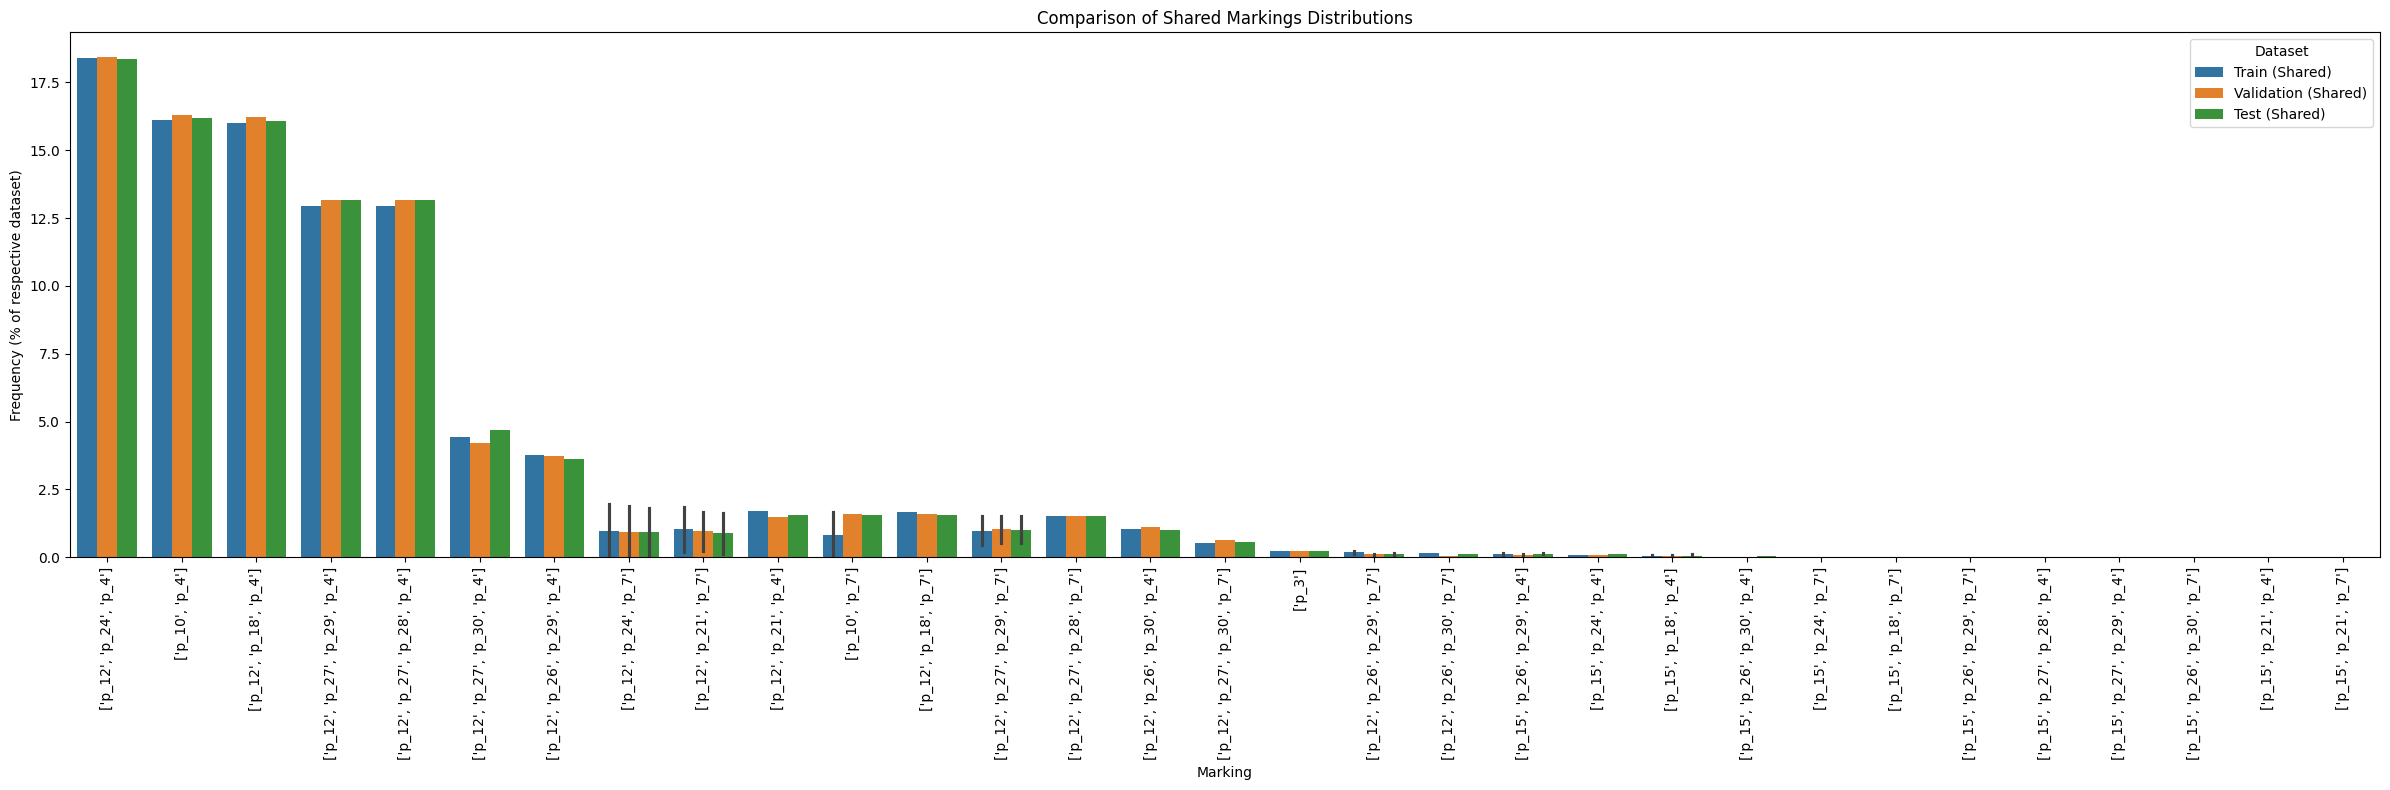

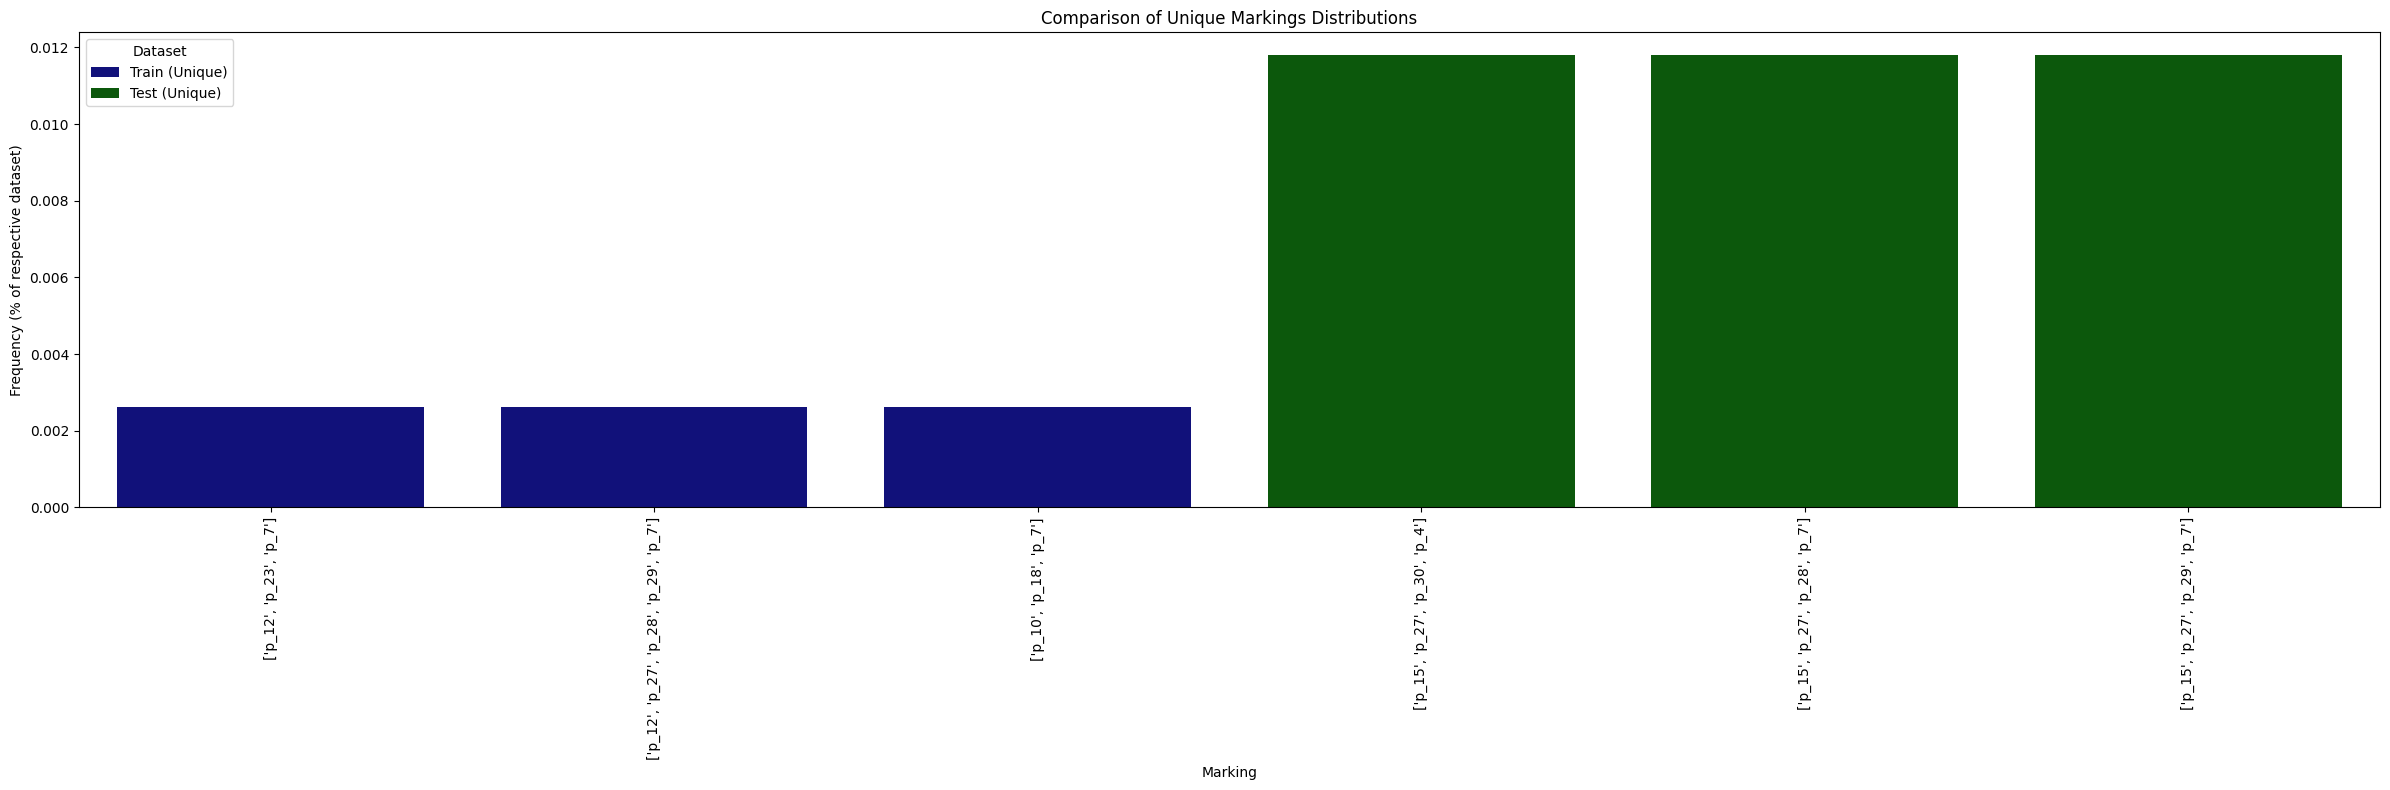

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

# Process train markings
markings_summary_train['marking_str'] = markings_summary_train['marking'].apply(lambda x: str(sorted([str(i) for i in x])))
markings_summary_train['freq'] = (markings_summary_train['count'] / markings_summary_train['count'].sum()) * 100
markings_summary_train['dataset'] = 'Train'

# Process validation markings
markings_summary_val['marking_str'] = markings_summary_val['marking'].apply(lambda x: str(sorted([str(i) for i in x])))
markings_summary_val['freq'] = (markings_summary_val['count'] / markings_summary_val['count'].sum()) * 100
markings_summary_val['dataset'] = 'Validation'

# Process test markings
markings_summary_test['marking_str'] = markings_summary_test['marking'].apply(lambda x: str(sorted([str(i) for i in x])))
markings_summary_test['freq'] = (markings_summary_test['count'] / markings_summary_test['count'].sum()) * 100
markings_summary_test['dataset'] = 'Test'

# Combine
combined_markings = pd.concat([
    markings_summary_train[['marking_str', 'freq', 'dataset']],
    markings_summary_val[['marking_str', 'freq', 'dataset']], 
    markings_summary_test[['marking_str', 'freq', 'dataset']]
])

# Identify unique markings
train_markings = set(markings_summary_train['marking_str'])
val_markings = set(markings_summary_val['marking_str'])
test_markings = set(markings_summary_test['marking_str'])

def get_category(row):
    m = row['marking_str']
    d = row['dataset']
    unique = False
    if d == 'Train' and m not in val_markings and m not in test_markings:
        unique = True
    elif d == 'Validation' and m not in train_markings and m not in test_markings:
        unique = True
    elif d == 'Test' and m not in train_markings and m not in val_markings:
        unique = True
    
    return f"{d} ({'Unique' if unique else 'Shared'})"

combined_markings['category'] = combined_markings.apply(get_category, axis=1)

# Split into Shared and Unique datasets
shared_data = combined_markings[combined_markings['category'].str.contains('Shared')]
unique_data = combined_markings[combined_markings['category'].str.contains('Unique')]

# Plot 1: Shared Markings
plt.figure(figsize=(24, 8))
palette_shared = {
    'Train (Shared)': 'tab:blue',
    'Validation (Shared)': 'tab:orange', 
    'Test (Shared)': 'tab:green'
}
sns.barplot(data=shared_data, x='marking_str', y='freq', hue='category', palette=palette_shared)
plt.xticks(rotation=90)
plt.title('Comparison of Shared Markings Distributions')
plt.ylabel('Frequency (% of respective dataset)')
plt.xlabel('Marking')
plt.legend(title='Dataset')
plt.tight_layout()
plt.show()

# Unique Markings
plt.figure(figsize=(24, 8))
palette_unique = {
    'Train (Unique)': 'darkblue',
    'Validation (Unique)': 'darkorange',
    'Test (Unique)': 'darkgreen'
}

if not unique_data.empty:
    sns.barplot(data=unique_data, x='marking_str', y='freq', hue='category', palette=palette_unique)
    plt.xticks(rotation=90)
    plt.title('Comparison of Unique Markings Distributions')
    plt.ylabel('Frequency (% of respective dataset)')
    plt.xlabel('Marking')
    plt.legend(title='Dataset')
    plt.tight_layout()
    plt.show()
else:
    print("No unique markings found across datasets.")

## Dtore datasets and credentials for Deep-NN

In [16]:
# object to create the tensors for the dnn models and further credentials
el_loader = EventLogLoader(event_log_location=event_log_location, event_log_properties=event_log_properties, prefix_df=pref_adopt_dataframe)

In [17]:
# 
test_set = el_loader.get_encoded_dataframe(type='test')
test_set

,id,org:resource,concept:name,time:timestamp,org:role,case:id,case:concept:name,case:BudgetNumber,case:DeclarationNumber,case:Amount,case_elapsed_time,event_elapsed_time,day_in_week,seconds_in_day
0,st_step 100047_0,STAFF MEMBER,Declaration SUBMITTED by EMPLOYEE,2018-04-20 13:55:22,EMPLOYEE,declaration 100042,declaration 100042,budget 86566,declaration number 100043,61.800099,0.0,NaN,4.0,50122.0
1,st_step 100045_0,STAFF MEMBER,Declaration APPROVED by ADMINISTRATION,2018-04-20 13:55:29,ADMINISTRATION,declaration 100042,declaration 100042,budget 86566,declaration number 100043,61.800099,7.0,7.0,4.0,50129.0
2,st_step 100044_0,STAFF MEMBER,Declaration APPROVED by BUDGET OWNER,2018-04-23 11:20:42,BUDGET OWNER,declaration 100042,declaration 100042,budget 86566,declaration number 100043,61.800099,249920.0,249913.0,0.0,40842.0
3,st_step 100046_0,STAFF MEMBER,Declaration FINAL_APPROVED by SUPERVISOR,2018-04-30 05:15:52,SUPERVISOR,declaration 100042,declaration 100042,budget 86566,declaration number 100043,61.800099,832830.0,582910.0,0.0,18952.0
4,dd_declaration 100042_19,SYSTEM,Request Payment,2018-05-01 07:55:03,UNDEFINED,declaration 100042,declaration 100042,budget 86566,declaration number 100043,61.800099,928781.0,95951.0,1.0,28503.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16342,EOS,EOS,EOS,NaT,EOS,EOS,declaration 99968,EOS,EOS,NaN,NaN,NaN,NaN,NaN
16343,EOS,EOS,EOS,NaT,EOS,EOS,declaration 99968,EOS,EOS,NaN,NaN,NaN,NaN,NaN
16344,EOS,EOS,EOS,NaT,EOS,EOS,declaration 99968,EOS,EOS,NaN,NaN,NaN,NaN,NaN
16345,EOS,EOS,EOS,NaT,EOS,EOS,declaration 99968,EOS,EOS,NaN,NaN,NaN,NaN,NaN


In [18]:
# train tensor dataset
train_set = el_loader.get_dataset('train')

# add markings to the train dataset credentials:
train_set.set_prefix_markings(markings=markings_train)

# save dataset 
torch.save(train_set, '../../../../encoded_data_conformal/BPIC20_DD/'+result_name+'_'+str(el_loader.encoder_decoder.min_suffix_size)+'_train.pkl')

categorical tensors:   0%|          | 0/3 [00:00<?, ?it/s]

concept:name:   0%|          | 0/7073 [00:00<?, ?it/s]

org:resource:   0%|          | 0/7073 [00:00<?, ?it/s]

org:role:   0%|          | 0/7073 [00:00<?, ?it/s]

continouous tensors:   0%|          | 0/4 [00:00<?, ?it/s]

case_elapsed_time:   0%|          | 0/7073 [00:00<?, ?it/s]

event_elapsed_time:   0%|          | 0/7073 [00:00<?, ?it/s]

day_in_week:   0%|          | 0/7073 [00:00<?, ?it/s]

seconds_in_day:   0%|          | 0/7073 [00:00<?, ?it/s]

static continuous:   0%|          | 0/38026 [00:00<?, ?it/s]

In [19]:
# Test get sizes and others
print("Min suffix size: ", train_set.min_suffix_size)

print("Categories and encoding params for dynamic categorical and continuous values: ", train_set.all_categories)
print("Categories and encoding params for static categorical and continuous values: ", train_set.all_static_categories)

print("Dynamic categorical tensor: ", train_set.categorical_tensors[0].size())
print("Dynamic continuous tensor: ", train_set.continuous_tensors[0].size())

print("Static categorical tensor: ", train_set.static_categorical_tensor.size())
print("Static continuous tensor: ", train_set.static_continuous_tensor.size())

print("Zero padding tensor: ", train_set.zero_padding.size())
print("EOS padding tensor: ",train_set.eos_padding.size())

print("Prefix petri net replay tensor: ", len(train_set.prefixes_petri_net_marking))
print(train_set.prefixes_petri_net_marking[0:3])

Min suffix size:  5
Categories and encoding params for dynamic categorical and continuous values:  ([('concept:name', 18, {'Declaration APPROVED by ADMINISTRATION': 1, 'Declaration APPROVED by BUDGET OWNER': 2, 'Declaration APPROVED by PRE_APPROVER': 3, 'Declaration FINAL_APPROVED by SUPERVISOR': 4, 'Declaration FOR_APPROVAL by ADMINISTRATION': 5, 'Declaration FOR_APPROVAL by SUPERVISOR': 6, 'Declaration REJECTED by ADMINISTRATION': 7, 'Declaration REJECTED by BUDGET OWNER': 8, 'Declaration REJECTED by EMPLOYEE': 9, 'Declaration REJECTED by MISSING': 10, 'Declaration REJECTED by PRE_APPROVER': 11, 'Declaration REJECTED by SUPERVISOR': 12, 'Declaration SAVED by EMPLOYEE': 13, 'Declaration SUBMITTED by EMPLOYEE': 14, 'EOS': 15, 'Payment Handled': 16, 'Request Payment': 17}), ('org:resource', 4, {'EOS': 1, 'STAFF MEMBER': 2, 'SYSTEM': 3}), ('org:role', 9, {'ADMINISTRATION': 1, 'BUDGET OWNER': 2, 'EMPLOYEE': 3, 'EOS': 4, 'MISSING': 5, 'PRE_APPROVER': 6, 'SUPERVISOR': 7, 'UNDEFINED': 8})], 

In [20]:
# train tensor dataset
val_set = el_loader.get_dataset('val')

# add markings to the train dataset credentials:
val_set.set_prefix_markings(markings=markings_val)

# save dataset 
torch.save(val_set, '../../../../encoded_data_conformal/BPIC20_DD/'+result_name+'_'+str(el_loader.encoder_decoder.min_suffix_size)+'_val.pkl')

categorical tensors:   0%|          | 0/3 [00:00<?, ?it/s]

concept:name:   0%|          | 0/1852 [00:00<?, ?it/s]

org:resource:   0%|          | 0/1852 [00:00<?, ?it/s]

org:role:   0%|          | 0/1852 [00:00<?, ?it/s]

continouous tensors:   0%|          | 0/4 [00:00<?, ?it/s]

case_elapsed_time:   0%|          | 0/1852 [00:00<?, ?it/s]

event_elapsed_time:   0%|          | 0/1852 [00:00<?, ?it/s]

day_in_week:   0%|          | 0/1852 [00:00<?, ?it/s]

seconds_in_day:   0%|          | 0/1852 [00:00<?, ?it/s]

static continuous:   0%|          | 0/9939 [00:00<?, ?it/s]

In [21]:
# Test get sizes and others
print("Min suffix size: ", val_set.min_suffix_size)

print("Categories and encoding params for dynamic categorical and continuous values: ", val_set.all_categories)
print("Categories and encoding params for static categorical and continuous values: ", val_set.all_static_categories)

print("Dynamic categorical tensor: ", val_set.categorical_tensors[0].size())
print("Dynamic continuous tensor: ", val_set.continuous_tensors[0].size())

print("Static categorical tensor: ", val_set.static_categorical_tensor.size())
print("Static continuous tensor: ", val_set.static_continuous_tensor.size())

print("Zero padding tensor: ", val_set.zero_padding.size())
print("EOS padding tensor: ",val_set.eos_padding.size())

print("Prefix petri net replay tensor: ", len(val_set.prefixes_petri_net_marking))
print(val_set.prefixes_petri_net_marking[0:3])

Min suffix size:  5
Categories and encoding params for dynamic categorical and continuous values:  ([('concept:name', 18, {'Declaration APPROVED by ADMINISTRATION': 1, 'Declaration APPROVED by BUDGET OWNER': 2, 'Declaration APPROVED by PRE_APPROVER': 3, 'Declaration FINAL_APPROVED by SUPERVISOR': 4, 'Declaration FOR_APPROVAL by ADMINISTRATION': 5, 'Declaration FOR_APPROVAL by SUPERVISOR': 6, 'Declaration REJECTED by ADMINISTRATION': 7, 'Declaration REJECTED by BUDGET OWNER': 8, 'Declaration REJECTED by EMPLOYEE': 9, 'Declaration REJECTED by MISSING': 10, 'Declaration REJECTED by PRE_APPROVER': 11, 'Declaration REJECTED by SUPERVISOR': 12, 'Declaration SAVED by EMPLOYEE': 13, 'Declaration SUBMITTED by EMPLOYEE': 14, 'EOS': 15, 'Payment Handled': 16, 'Request Payment': 17}), ('org:resource', 4, {'EOS': 1, 'STAFF MEMBER': 2, 'SYSTEM': 3}), ('org:role', 9, {'ADMINISTRATION': 1, 'BUDGET OWNER': 2, 'EMPLOYEE': 3, 'EOS': 4, 'MISSING': 5, 'PRE_APPROVER': 6, 'SUPERVISOR': 7, 'UNDEFINED': 8})], 

In [22]:
# train tensor dataset
test_set = el_loader.get_dataset('test')

# add markings to the train dataset credentials:
test_set.set_prefix_markings(markings=markings_test)

# save dataset 
torch.save(test_set, '../../../../encoded_data_conformal/BPIC20_DD/'+result_name+'_'+str(el_loader.encoder_decoder.min_suffix_size)+'_test.pkl')

categorical tensors:   0%|          | 0/3 [00:00<?, ?it/s]

concept:name:   0%|          | 0/1575 [00:00<?, ?it/s]

org:resource:   0%|          | 0/1575 [00:00<?, ?it/s]

org:role:   0%|          | 0/1575 [00:00<?, ?it/s]

continouous tensors:   0%|          | 0/4 [00:00<?, ?it/s]

case_elapsed_time:   0%|          | 0/1575 [00:00<?, ?it/s]

event_elapsed_time:   0%|          | 0/1575 [00:00<?, ?it/s]

day_in_week:   0%|          | 0/1575 [00:00<?, ?it/s]

seconds_in_day:   0%|          | 0/1575 [00:00<?, ?it/s]

static continuous:   0%|          | 0/8472 [00:00<?, ?it/s]

In [23]:
# Test get sizes and others
print("Min suffix size: ", test_set.min_suffix_size)

print("Categories and encoding params for dynamic categorical and continuous values: ", test_set.all_categories)
print("Categories and encoding params for static categorical and continuous values: ", test_set.all_static_categories)

print("Dynamic categorical tensor: ", test_set.categorical_tensors[0].size())
# print("Dynamic categorical tensor examples: ", test_set.categorical_tensors[0][10:55])
print("Dynamic continuous tensor: ", test_set.continuous_tensors[0].size())

print("Static categorical tensor: ", test_set.static_categorical_tensor.size())
print("Static continuous tensor: ", test_set.static_continuous_tensor.size())

print("Zero padding tensor: ", test_set.zero_padding.size())
print("EOS padding tensor: ",test_set.eos_padding.size())
# print("Zero padds: ", test_set.zero_padding[35:41])
# print("EOS padds: ", test_set.eos_padding[35:41])

print("Prefix petri net replay tensor: ", len(test_set.prefixes_petri_net_marking))
print(test_set.prefixes_petri_net_marking[0:3])

Min suffix size:  5
Categories and encoding params for dynamic categorical and continuous values:  ([('concept:name', 18, {'Declaration APPROVED by ADMINISTRATION': 1, 'Declaration APPROVED by BUDGET OWNER': 2, 'Declaration APPROVED by PRE_APPROVER': 3, 'Declaration FINAL_APPROVED by SUPERVISOR': 4, 'Declaration FOR_APPROVAL by ADMINISTRATION': 5, 'Declaration FOR_APPROVAL by SUPERVISOR': 6, 'Declaration REJECTED by ADMINISTRATION': 7, 'Declaration REJECTED by BUDGET OWNER': 8, 'Declaration REJECTED by EMPLOYEE': 9, 'Declaration REJECTED by MISSING': 10, 'Declaration REJECTED by PRE_APPROVER': 11, 'Declaration REJECTED by SUPERVISOR': 12, 'Declaration SAVED by EMPLOYEE': 13, 'Declaration SUBMITTED by EMPLOYEE': 14, 'EOS': 15, 'Payment Handled': 16, 'Request Payment': 17}), ('org:resource', 4, {'EOS': 1, 'STAFF MEMBER': 2, 'SYSTEM': 3}), ('org:role', 9, {'ADMINISTRATION': 1, 'BUDGET OWNER': 2, 'EMPLOYEE': 3, 'EOS': 4, 'MISSING': 5, 'PRE_APPROVER': 6, 'SUPERVISOR': 7, 'UNDEFINED': 8})], 